In [ ]:
!pip uninstall -y pyarrow numpy
!pip install numpy==1.26.0 pyarrow==15.0.2


Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.3/38.3 MB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.12.0.

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


In [ ]:
# Core libraries
!pip install numpy pandas scikit-learn scipy

# NLP / Preprocessing
!pip install nltk regex indic-nlp-library indic-transliteration langdetect

# Deep Learning + Transformers
!pip install torch tensorflow transformers sentencepiece

# Visualization
!pip install matplotlib seaborn

# Deployment (for Streamlit demo, if you run locally)
!pip install streamlit

# Optional (for improvements / explainability)
!pip install fasttext optuna shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 3.9 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=47eb6d7b6357d69bccb3627ceef56b2247f6f67a3d83d35e37c105fbfadc6c5e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 154.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 31.2 MB/s eta 0:00:00
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498214 sha256=8739d8773d022e22e2fa82dcf7ae19a3294999bcdddf300507773c0b78ab9768
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
  Created wheel for lime: file

In [ ]:
!pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 5.6 MB/s eta 0:00:00


PREPROCESSING

In [ ]:
import pandas as pd
import neattext.functions as nfx

# Load dataset
path = r"/content/NLP_DATASET  (4).csv"
df = pd.read_csv(path)

# Remove empty rows
df = df.dropna(subset=["Text"])

# Keep only necessary columns
df = df.loc[:, ["ID", "Category", "Text", "Language", "Emotion"]]

# Normalize emotions
mapping = {
    "Satisfied": "Happy", "Good": "Happy",
    "Disgused": "Disgusted", "disgusted": "Disgusted",
    "Sad": "Sad", "sad": "Sad",
    "Disappointed": "Disappointed", "disappointed": "Disappointed",
    "Angry": "Angry", "angry": "Angry",
    "Neutral": "Neutral", "neutral": "Neutral",
    "Confused": "Confused", "confused": "Confused",
    "Surprised": "Surprised", "surprised": "Surprised",
    "Happy": "Happy", "happy": "Happy","good":"Happy"," Disappointed": "Disappointed","Disappointed ": "Disappointed"
}
df['Emotion'] = df['Emotion'].replace(mapping)

# Clean text
df['Clean_Text'] = df['Text'].astype(str).apply(nfx.remove_userhandles)
df['Clean_Text'] = df['Clean_Text'].apply(nfx.remove_stopwords)

print(df['Emotion'].value_counts())
print(df.head())

Emotion
Happy           291
Disappointed    166
Angry           128
Neutral         124
Sad             121
Disgusted        97
Confused         87
Surprised        81
Name: count, dtype: int64
   ID          Category                                               Text  \
0   1  Books and Novels  மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...   
1   2     Mobile phones  மிகவும் நல்ல பேட்டரி லைஃப், ஒரு நாள் முழுக்க ச...   
2   3  Books and Novels  புத்தகத்தின் அச்சு தரம் மிகவும் மோசம், எழுத்து...   
3   4       Electronics  பட்டன் வேலை செய்யவில்லை, இரண்டு நாட்களில் பழுத...   
4   5       Electronics  சிறந்த வேகத்தில் வேலை செய்கிறது, ஹீட்டிங் பிரச...   

  Language       Emotion                                         Clean_Text  
0    Tamil         Happy  மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...  
1    Tamil         Happy  மிகவும் நல்ல பேட்டரி லைஃப், ஒரு நாள் முழுக்க ச...  
2    Tamil  Disappointed  புத்தகத்தின் அச்சு தரம் மிகவும் மோசம், எழுத்து...  
3    Tamil         Angry 

In [ ]:
!pip install huggingface_hub[hf_xet]

In [ ]:
import pandas as pd
from transformers import pipeline
import math

# ✅ Load multilingual zero-shot classifier
classifier = pipeline("zero-shot-classification",
                      model="joeddav/xlm-roberta-large-xnli",
                      framework="pt",
                      device=-1)   # use 0 if you have GPU, -1 for CPU

# ✅ Define your emotion categories
emotions = ["Happy", "Sad", "Confused", "Angry",
            "Surprised", "Disgusted", "Neutral", "Disappointed"]

# ✅ Load your dataset
df = pd.read_csv(r"/content/NLP_DATASET  (4).csv")
print("Before:", df.head())

# ✅ Batch function
def get_emotions_batch(texts):
    try:
        results = classifier(texts, emotions)
        preds = [r['labels'][0] for r in results]
        return preds
    except Exception as e:
        print("Error in batch:", e)
        return ["Unknown"] * len(texts)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


Before:    ID          Category                                               Text  \
0   1  Books and Novels  மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...   
1   2     Mobile phones  மிகவும் நல்ல பேட்டரி லைஃப், ஒரு நாள் முழுக்க ச...   
2   3  Books and Novels  புத்தகத்தின் அச்சு தரம் மிகவும் மோசம், எழுத்து...   
3   4       Electronics  பட்டன் வேலை செய்யவில்லை, இரண்டு நாட்களில் பழுத...   
4   5       Electronics  சிறந்த வேகத்தில் வேலை செய்கிறது, ஹீட்டிங் பிரச...   

  Language       Emotion  
0    Tamil         Happy  
1    Tamil         Happy  
2    Tamil  Disappointed  
3    Tamil         Angry  
4    Tamil         Happy  


In [ ]:
new_path = r"/content/labelled_dataset.csv"

In [ ]:
import pandas as pd
import neattext.functions as nfx

# Load dataset

new_df = pd.read_csv(new_path)

# Remove empty rows
new_df = new_df.dropna(subset=["Text"])

# Keep only necessary columns
new_df = new_df.loc[:, ["ID", "Category", "Text", "Language", "Predicted_Emotion"]]

# Normalize emotions
mapping = {
    "Satisfied": "Happy", "Good": "Happy",
    "Disgused": "Disgusted", "disgusted": "Disgusted",
    "Sad": "Sad", "sad": "Sad",
    "Disappointed": "Disappointed", "disappointed": "Disappointed",
    "Angry": "Angry", "angry": "Angry",
    "Neutral": "Neutral", "neutral": "Neutral",
    "Confused": "Confused", "confused": "Confused",
    "Surprised": "Surprised", "surprised": "Surprised",
    "Happy": "Happy", "happy": "Happy","good":"Happy"," Disappointed": "Disappointed","Disappointed ": "Disappointed"
}
new_df['Predicted_Emotion'] = new_df['Predicted_Emotion'].replace(mapping)

# Clean text
new_df['Clean_Text'] = new_df['Text'].astype(str).apply(nfx.remove_userhandles)
new_df['Clean_Text'] = new_df['Clean_Text'].apply(nfx.remove_stopwords)

print(new_df['Predicted_Emotion'].value_counts())
print(new_df.head())

Predicted_Emotion
Surprised       842
Disappointed    284
Happy           137
Confused        129
Sad             105
Neutral          95
Angry            22
Disgusted         5
Name: count, dtype: int64
   ID          Category                                               Text  \
0   1  Books and Novels  மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...   
1   2     Mobile phones  மிகவும் நல்ல பேட்டரி லைஃப், ஒரு நாள் முழுக்க ச...   
2   3  Books and Novels  புத்தகத்தின் அச்சு தரம் மிகவும் மோசம், எழுத்து...   
3   4       Electronics  பட்டன் வேலை செய்யவில்லை, இரண்டு நாட்களில் பழுத...   
4   5       Electronics  சிறந்த வேகத்தில் வேலை செய்கிறது, ஹீட்டிங் பிரச...   

  Language Predicted_Emotion  \
0    Tamil         Surprised   
1    Tamil             Happy   
2    Tamil      Disappointed   
3    Tamil      Disappointed   
4    Tamil             Happy   

                                          Clean_Text  
0  மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...  
1  மிகவும் நல்ல பேட்டரி 

In [ ]:
import pandas as pd

# Load the dataset
l_df = pd.read_csv("labelled_dataset.csv")

# 1️⃣ Check for nulls in the entire dataset
print("Nulls in each column:")
print(l_df.isnull().sum())

# 2️⃣ See rows where any of the key columns are null
null_rows = l_df[l_df[['Text', 'Emotion', 'Predicted_Emotion']].isnull().any(axis=1)]
print("\nRows with nulls in Text, Emotion, or Predicted Emotion:")
print(null_rows)

# 3️⃣ Optional: Save these rows to a new CSV to inspect
null_rows.to_csv("null_rows.csv", index=False)
print("\nRows with nulls saved to 'null_rows.csv'.")

Nulls in each column:
ID                   0
Category             0
Text                 0
Language             0
Emotion              0
Predicted_Emotion    0
dtype: int64

Rows with nulls in Text, Emotion, or Predicted Emotion:
Empty DataFrame
Columns: [ID, Category, Text, Language, Emotion, Predicted_Emotion]
Index: []

Rows with nulls saved to 'null_rows.csv'.


In [ ]:
# 📌 Install necessary libraries first (run in terminal / notebook)
# pip install indic-nlp-library nltk langdetect indic-transliteration regex

import re
import pandas as pd
from langdetect import detect
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.transliterate.unicode_transliterate import UnicodeIndicTransliterator
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# ------------------------------
# Load dataset
# ------------------------------
l_df = pd.read_csv("labelled_dataset.csv")

# ------------------------------
# 1. Language Detection (sanity check)
# ------------------------------
def detect_lang(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

l_df['Detected_Lang'] = l_df['Text'].astype(str).apply(detect_lang)

# ------------------------------
# 2. Text Normalization (Robust for Tamil & Telugu)
# ------------------------------
factory = IndicNormalizerFactory()
tamil_normalizer = factory.get_normalizer("ta")
telugu_normalizer = factory.get_normalizer("te")

def normalize_text(text, lang):
    text = str(text).lower().strip()

    if lang in ["Tamil", "ta"]:  # support both
        text = re.sub(r'[^0-9A-Za-z\u0B80-\u0BFF\s]', '', text)
        text = tamil_normalizer.normalize(text)
    elif lang in ["Telugu", "te"]:
        text = re.sub(r'[^0-9A-Za-z\u0C00-\u0C7F\s]', '', text)
        text = telugu_normalizer.normalize(text)
    else:  # fallback English
        text = re.sub(r'[^0-9A-Za-z\s]', '', text)

    return text if text.strip() != "" else str(text)  # safeguard

l_df['Normalized_Text'] = l_df.apply(
    lambda row: normalize_text(row['Text'], row['Language']), axis=1
)

# ------------------------------
# 3. Stopword Removal (with safeguard)
# ------------------------------
tamil_stopwords = [
    "என்று","அவர்","ஆகிய","உள்ளது","ஒரு","இது","என","அது","அவர்கள்",
    "என்","எங்கள்","நான்","உங்கள்","என்ன","ஏன்","எப்படி","இல்லை","ஆம்",
    "மிகவும்","பல","சில","எந்த","இந்த","அந்த","இங்கே","அங்கே",
    "இப்போது","பின்னர்","எப்பொழுது","அல்லது","ஆனால்","இருந்து",
    "மேலும்","ஆக","கொண்டு","போன்ற","வைத்து","வரை","மட்டும்"
]

telugu_stopwords = [
    "అది","అవి","ఈ","ఆ","ఇది","ఇవి","అక్కడ","ఇక్కడ",
    "అతను","ఆమె","వారు","మనం","నేను","మీరు","మా","నా",
    "ఎందుకు","ఎలా","లేదు","అవును","కూడా","మాత్రమే",
    "ఎప్పుడు","తర్వాత","లేదా","కాని","నుండి","వరకు",
    "తో","వంటి","కావున","చాలా","కొన్ని","ఎవరైనా","ఎవరు"
]

def remove_stopwords(text, lang):
    words = text.split()
    if lang in ["Tamil", "ta"]:
        words = [w for w in words if w not in tamil_stopwords]
    elif lang in ["Telugu", "te"]:
        words = [w for w in words if w not in telugu_stopwords]

    return " ".join(words) if words else text  # fallback to original text if empty

l_df['Clean_Text'] = l_df.apply(
    lambda row: remove_stopwords(row['Normalized_Text'], row['Language']), axis=1
)

# ------------------------------
# 4. Tokenization (avoid [""] case)
# ------------------------------
def tokenize_text(text, lang):
    tokens = list(indic_tokenize.trivial_tokenize(text, lang))
    return [t for t in tokens if t.strip() != ""]  # remove empty tokens

l_df['Tokens'] = l_df.apply(
    lambda row: tokenize_text(row['Clean_Text'], "ta" if row['Language'] in ["Tamil","ta"] else "te"), axis=1
)

# ------------------------------
# 5. OPTIONAL: Transliteration (Tanglish → Tamil/Telugu script)
# ------------------------------
def transliterate_text(text, lang):
    if lang in ["Tamil", "ta"]:
        return UnicodeIndicTransliterator.transliterate(text, "en", "ta")
    elif lang in ["Telugu", "te"]:
        return UnicodeIndicTransliterator.transliterate(text, "en", "te")
    return text

# ------------------------------
# Example checks
# ------------------------------
sample_tamil = "இந்த போன் மிகவும் நல்லது ஆனால் பேட்டரி லைஃப் குறைவாக உள்ளது"
print("Tamil Before:", sample_tamil)
print("Tamil After:", remove_stopwords(normalize_text(sample_tamil, "Tamil"), "Tamil"))

sample_telugu = "ఈ ఫోన్ చాలా బాగుంది కానీ కెమెరా క్వాలిటీ సగటు"
print("Telugu Before:", sample_telugu)
print("Telugu After:", remove_stopwords(normalize_text(sample_telugu, "Telugu"), "Telugu"))

# ------------------------------
# Save cleaned dataset
# ------------------------------
l_df.to_csv("preprocessed_dataset.csv", index=False, encoding="utf-8-sig")
print("✅ Preprocessing completed and saved!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tamil Before: இந்த போன் மிகவும் நல்லது ஆனால் பேட்டரி லைஃப் குறைவாக உள்ளது
Tamil After: போன் நல்லது பேட்டரி லைஃப் குறைவாக
Telugu Before: ఈ ఫోన్ చాలా బాగుంది కానీ కెమెరా క్వాలిటీ సగటు
Telugu After: ఫోన్ బాగుంది కానీ కెమెరా క్వాలిటీ సగటు
✅ Preprocessing completed and saved!


In [ ]:
import pandas as pd

# ✅ Load preprocessed dataset
processed_df = pd.read_csv(r"/content/preprocessed_dataset.csv")

# ✅ Basic info
print("Dataset Info:")
print(processed_df.info())

# ✅ Check null values
print("\nNull Values per Column:")
print(processed_df.isnull().sum())

# ✅ Distribution of emotions
print("\nEmotion Distribution:")
print(processed_df['Predicted_Emotion'].value_counts())

# ✅ Preview some rows
print("\nSample Rows:")
print(processed_df.head(10))

# ✅ Preview how text looks after preprocessing
print("\nRandom Sample of Cleaned Texts:")
print(processed_df['Clean_Text'].sample(10, random_state=42).tolist())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619 entries, 0 to 1618
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 1619 non-null   int64 
 1   Category           1619 non-null   object
 2   Text               1619 non-null   object
 3   Language           1619 non-null   object
 4   Emotion            1619 non-null   object
 5   Predicted_Emotion  1619 non-null   object
 6   Detected_Lang      1619 non-null   object
 7   Normalized_Text    1619 non-null   object
 8   Clean_Text         1619 non-null   object
 9   Tokens             1619 non-null   object
dtypes: int64(1), object(9)
memory usage: 126.6+ KB
None

Null Values per Column:
ID                   0
Category             0
Text                 0
Language             0
Emotion              0
Predicted_Emotion    0
Detected_Lang        0
Normalized_Text      0
Clean_Text           0
Tokens               0
dty

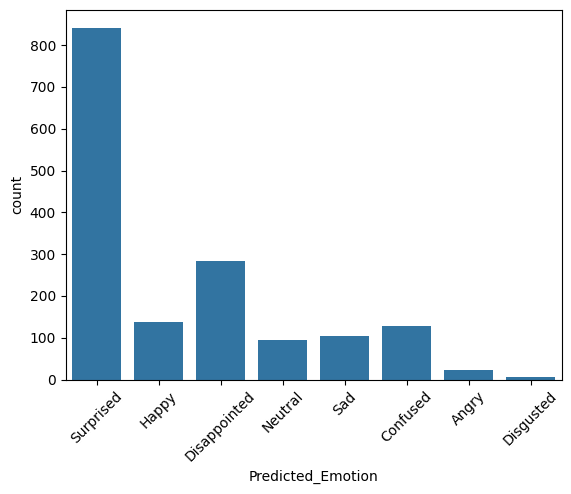

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Now your plot will work
sns.countplot(x='Predicted_Emotion', data=processed_df)
plt.xticks(rotation=45)  # Optional: rotate x labels if they overlap
plt.show()


In [ ]:
# Data Cleaning
dir(nfx)

['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

In [ ]:
processed_df

,ID,Category,Text,Language,Emotion,Predicted_Emotion,Detected_Lang,Normalized_Text,Clean_Text,Tokens
0,1,Books and Novels,மிக அருமையான புதினம். நம் வாழ்நாளில் அவசியம் ப...,Tamil,Happy,Surprised,ta,மிக அருமையான புதினம் நம் வாழ்நாளில் அவசியம் பட...,மிக அருமையான புதினம் நம் வாழ்நாளில் அவசியம் பட...,"['மிக', 'அருமையான', 'புதினம்', 'நம்', 'வாழ்நாள..."
1,2,Mobile phones,"மிகவும் நல்ல பேட்டரி லைஃப், ஒரு நாள் முழுக்க ச...",Tamil,Happy,Happy,ta,மிகவும் நல்ல பேட்டரி லைஃப் ஒரு நாள் முழுக்க சா...,நல்ல பேட்டரி லைஃப் நாள் முழுக்க சார்ஜ் பிடிக்கும்,"['நல்ல', 'பேட்டரி', 'லைஃப்', 'நாள்', 'முழுக்க'..."
2,3,Books and Novels,"புத்தகத்தின் அச்சு தரம் மிகவும் மோசம், எழுத்து...",Tamil,Disappointed,Disappointed,ta,புத்தகத்தின் அச்சு தரம் மிகவும் மோசம் எழுத்துக...,புத்தகத்தின் அச்சு தரம் மோசம் எழுத்துக்கள் தெள...,"['புத்தகத்தின்', 'அச்சு', 'தரம்', 'மோசம்', 'எழ..."
3,4,Electronics,"பட்டன் வேலை செய்யவில்லை, இரண்டு நாட்களில் பழுத...",Tamil,Angry,Disappointed,ta,பட்டன் வேலை செய்யவில்லை இரண்டு நாட்களில் பழுதா...,பட்டன் வேலை செய்யவில்லை இரண்டு நாட்களில் பழுதா...,"['பட்டன்', 'வேலை', 'செய்யவில்லை', 'இரண்டு', 'ந..."
4,5,Electronics,"சிறந்த வேகத்தில் வேலை செய்கிறது, ஹீட்டிங் பிரச...",Tamil,Happy,Happy,ta,சிறந்த வேகத்தில் வேலை செய்கிறது ஹீட்டிங் பிரச்...,சிறந்த வேகத்தில் வேலை செய்கிறது ஹீட்டிங் பிரச்சனை,"['சிறந்த', 'வேகத்தில்', 'வேலை', 'செய்கிறது', '..."
...,...,...,...,...,...,...,...,...,...,...
1614,1615,appliances,ఫ్రిజ్ పనితనం అతి ఆశ్చర్యంగా ఉంది.,Telugu,Surprised,Surprised,te,ఫ్రిజ్ పనితనం అతి ఆశ్చర్యంగా ఉంది,ఫ్రిజ్ పనితనం అతి ఆశ్చర్యంగా ఉంది,"['ఫ్రిజ్', 'పనితనం', 'అతి', 'ఆశ్చర్యంగా', 'ఉంది']"
1615,1616,appliances,మిక్సర్ ఆవుట్పుట్ నా అంచనాలకు మించినది.,Telugu,Surprised,Surprised,te,మిక్సర్ ఆవుట్పుట్ నా అంచనాలకు మించినది,మిక్సర్ ఆవుట్పుట్ అంచనాలకు మించినది,"['మిక్సర్', 'ఆవుట్పుట్', 'అంచనాలకు', 'మించినది']"
1616,1617,appliances,వాషింగ్ మషీన్ ఇవల్యూషన్ చాలా స్పీడుగా వచ్చింది.,Telugu,Surprised,Surprised,te,వాషింగ్ మషీన్ ఇవల్యూషన్ చాలా స్పీడుగా వచ్చింది,వాషింగ్ మషీన్ ఇవల్యూషన్ స్పీడుగా వచ్చింది,"['వాషింగ్', 'మషీన్', 'ఇవల్యూషన్', 'స్పీడుగా', ..."
1617,1618,appliances,చిమ్నీ టెక్నాలజీ చాలా ఆధునికంగా ఉంది.,Telugu,Surprised,Surprised,te,చిమ్నీ టెక్నాలజీ చాలా ఆధునికంగా ఉంది,చిమ్నీ టెక్నాలజీ ఆధునికంగా ఉంది,"['చిమ్నీ', 'టెక్నాలజీ', 'ఆధునికంగా', 'ఉంది']"


In [ ]:
# Features & Labels
Xfeatures = processed_df['Clean_Text']
ylabels = processed_df['Emotion']

In [ ]:
!pip install -U transformers

In [ ]:
!pip install tf-keras

Before balancing:
 Predicted_Emotion
Surprised       842
Disappointed    284
Happy           137
Confused        129
Sad             105
Neutral          95
Angry            22
Disgusted         5
Name: count, dtype: int64
✅ Fast augmentation completed! Saved as balanced_dataset_light.csv
After balancing:
 Predicted_Emotion
Surprised       842
Happy           842
Disappointed    842
Neutral         842
Sad             842
Confused        842
Angry           842
Disgusted       842
Name: count, dtype: int64


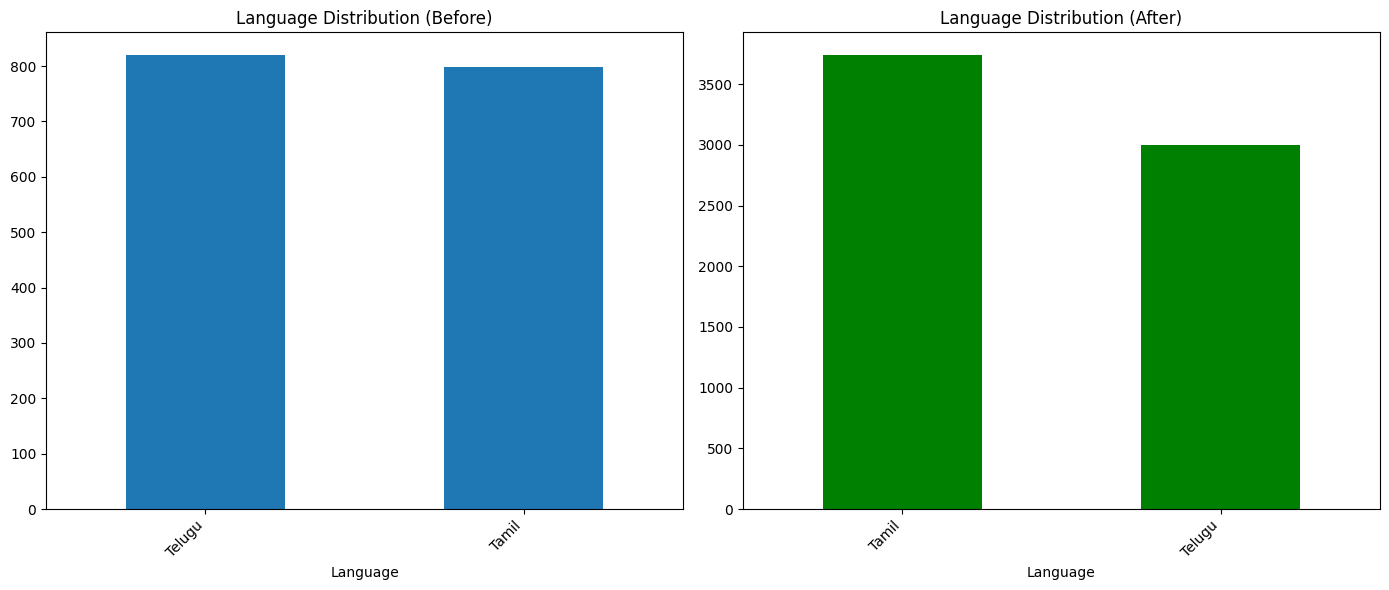

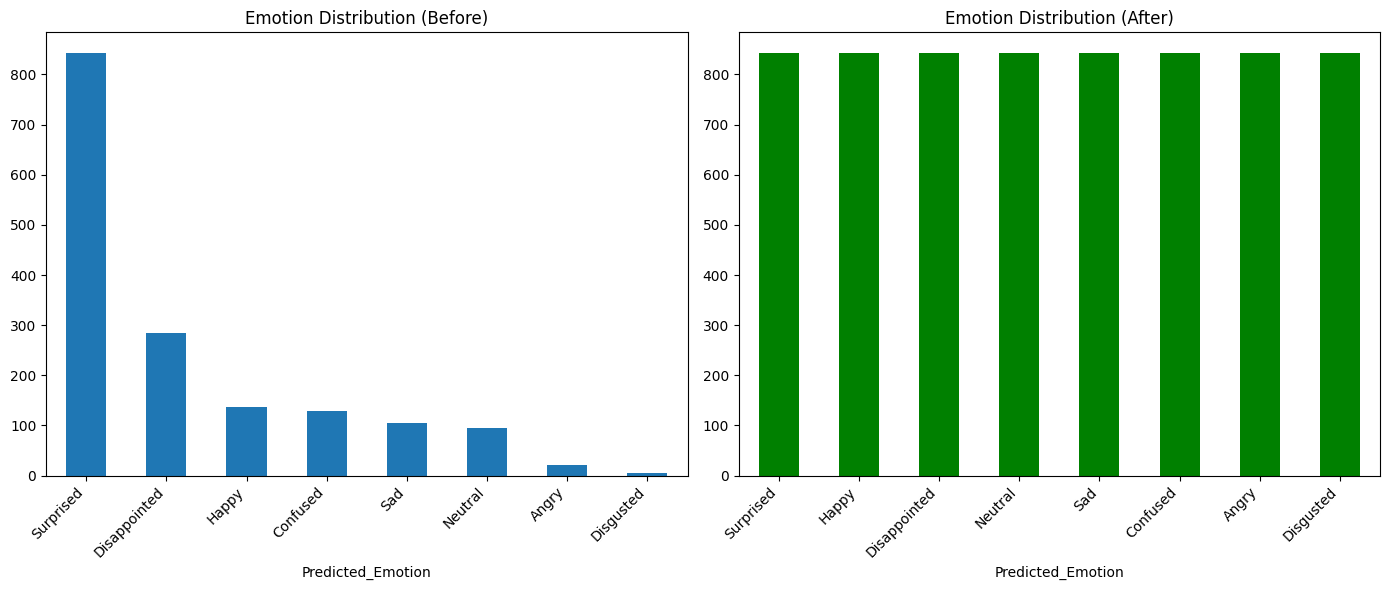

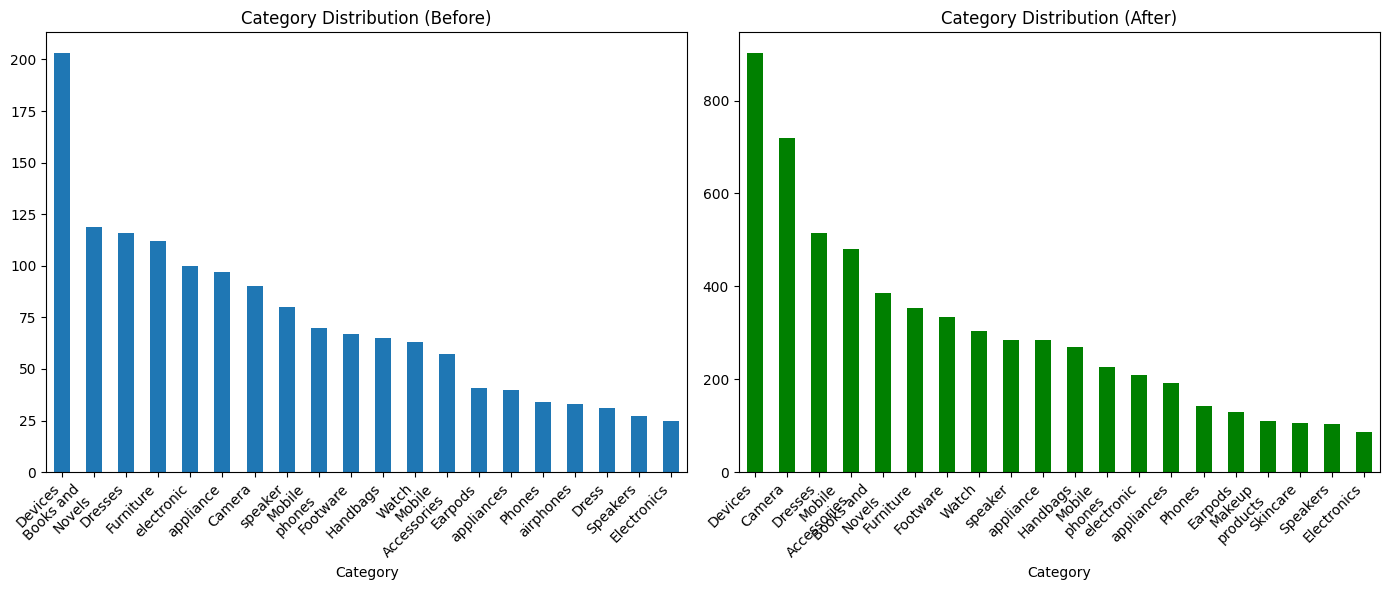

In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt

# ===============================
# 1. Load Dataset
# ===============================
d_f = pd.read_csv(r"/content/preprocessed_dataset.csv")

print("Before balancing:\n", d_f['Predicted_Emotion'].value_counts())

# Ensure text is string
d_f['Clean_Text'] = d_f['Clean_Text'].astype(str).fillna("")

# ===============================
# 2. EDA Functions
# ===============================
def random_deletion(text, p=0.1):
    words = str(text).split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return " ".join(new_words) if new_words else text

def random_swap(text, n=1):
    words = str(text).split()
    for _ in range(n):
        if len(words) > 1:
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

def eda_augment(text):
    text = str(text)
    choice = random.choice(["delete", "swap", "none"])
    if choice == "delete":
        return random_deletion(text)
    elif choice == "swap":
        return random_swap(text)
    else:
        return text

# ===============================
# 3. Augmentation Loop
# ===============================
augmented_rows = []
max_samples = d_f['Predicted_Emotion'].value_counts().max()

for emotion, count in d_f['Predicted_Emotion'].value_counts().items():
    if count < max_samples:  # minority class → augment
        needed = max_samples - count
        subset = d_f[d_f['Predicted_Emotion'] == emotion]

        for i in range(needed):
            row = subset.iloc[i % len(subset)]
            text = row['Clean_Text']
            aug_text = eda_augment(text)

            augmented_rows.append({
                "ID": f"eda_{emotion}_{i}",
                "Category": row['Category'],
                "Text": row['Text'],
                "Language": row['Language'],
                "Predicted_Emotion": emotion,
                "Clean_Text": aug_text
            })

aug_df = pd.DataFrame(augmented_rows)

# ===============================
# 4. Merge & Save
# ===============================
balanced_df = pd.concat([d_f, aug_df], ignore_index=True)
balanced_df.to_csv("balanced_dataset_light.csv", index=False, encoding="utf-8-sig")

print("✅ Fast augmentation completed! Saved as balanced_dataset_light.csv")
print("After balancing:\n", balanced_df['Predicted_Emotion'].value_counts())

# ===============================
# 5. Visualization
# ===============================
import matplotlib.pyplot as plt
import textwrap

def plot_counts(before, after, column, title, top_n=20):
    plt.figure(figsize=(14,6))

    # Take top N categories for readability
    before_counts = before[column].value_counts().head(top_n)
    after_counts = after[column].value_counts().head(top_n)

    # Wrap long labels
    before_labels = ['\n'.join(textwrap.wrap(str(lbl), 12)) for lbl in before_counts.index]
    after_labels = ['\n'.join(textwrap.wrap(str(lbl), 12)) for lbl in after_counts.index]

    # Before
    plt.subplot(1,2,1)
    before_counts.plot(kind='bar')
    plt.title(f"{title} (Before)")
    plt.xticks(range(len(before_labels)), before_labels, rotation=45, ha="right")

    # After
    plt.subplot(1,2,2)
    after_counts.plot(kind='bar', color="green")
    plt.title(f"{title} (After)")
    plt.xticks(range(len(after_labels)), after_labels, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


# Plot for Language, Emotion, Category
plot_counts(d_f, balanced_df, "Language", "Language Distribution")
plot_counts(d_f, balanced_df, "Predicted_Emotion", "Emotion Distribution")
plot_counts(d_f, balanced_df, "Category", "Category Distribution")


In [ ]:
import pandas as pd

# Load the CSV
updated_df = pd.read_csv(r"/content/balanced_dataset_light.csv")

# Total number of data points
print("Total data points after augmentation:", len(updated_df))

Total data points after augmentation: 6736


In [ ]:
import pandas as pd


# Count samples per language
counts = updated_df['Language'].value_counts()
print(counts)


Language
Tamil     3740
Telugu    2996
Name: count, dtype: int64


MODEL BUILDING/TRAINING

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    updated_df,
    test_size=0.2,
    stratify=updated_df['Predicted_Emotion'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Predicted_Emotion'],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))


Train size: 5388
Validation size: 674
Test size: 674


BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# --- Assume you have train_df, val_df, and test_df from your split ---
# (If you don't have them in memory, re-run your train_test_split cell)

# 1. Create the TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# 2. Fit on train and transform all splits
X_train = tfidf.fit_transform(train_df['Clean_Text'])
X_val = tfidf.transform(val_df['Clean_Text'])
X_test = tfidf.transform(test_df['Clean_Text'])

# 3. Use LabelEncoder for the labels (REQUIRED for XGBoost)
le = LabelEncoder()

# Fit on the training labels and transform all
y_train_enc = le.fit_transform(train_df['Predicted_Emotion'])
y_val_enc = le.transform(val_df['Predicted_Emotion'])
y_test_enc = le.transform(test_df['Predicted_Emotion'])

print("Data is ready for classic ML models!")
print("Label classes:", le.classes_)

Data is ready for classic ML models!
Label classes: ['Angry' 'Confused' 'Disappointed' 'Disgusted' 'Happy' 'Neutral' 'Sad'
 'Surprised']


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("--- Training Random Forest (Bagging) ---")

# Initialize the model
# n_jobs=-1 uses all your CPU cores in Colab to make it faster
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_clf.fit(X_train, y_train_enc)

# Get predictions on the VALIDATION set
y_pred_rf = rf_clf.predict(X_val)

# Show the results
print("\nValidation Results for Random Forest:")
print(f"Accuracy: {accuracy_score(y_val_enc, y_pred_rf) * 100:.2f}%")
print(classification_report(y_val_enc, y_pred_rf, target_names=le.classes_))

--- Training Random Forest (Bagging) ---

Validation Results for Random Forest:
Accuracy: 91.69%
              precision    recall  f1-score   support

       Angry       1.00      0.99      0.99        84
    Confused       0.97      0.93      0.95        84
Disappointed       0.88      0.90      0.89        84
   Disgusted       0.99      1.00      0.99        85
       Happy       0.87      0.96      0.92        84
     Neutral       0.86      0.96      0.91        84
         Sad       0.86      0.92      0.89        85
   Surprised       0.92      0.67      0.77        84

    accuracy                           0.92       674
   macro avg       0.92      0.92      0.91       674
weighted avg       0.92      0.92      0.91       674



In [ ]:
# XGBoost is not pre-installed in all Colab sessions, so let's be safe
!pip install xgboost

from xgboost import XGBClassifier

print("\n--- Training XGBoost (Boosting) ---")

# Initialize the model
# XGBoost is complex, but these defaults are a good start
xgb_clf = XGBClassifier(
    objective='multi:softmax',  # We have multiple classes
    num_class=len(le.classes_), # Tell it how many classes
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_clf.fit(X_train, y_train_enc)

# Get predictions on the VALIDATION set
y_pred_xgb = xgb_clf.predict(X_val)

# Show the results
print("\nValidation Results for XGBoost:")
print(f"Accuracy: {accuracy_score(y_val_enc, y_pred_xgb) * 100:.2f}%")
print(classification_report(y_val_enc, y_pred_xgb, target_names=le.classes_))


--- Training XGBoost (Boosting) ---

Validation Results for XGBoost:
Accuracy: 87.09%
              precision    recall  f1-score   support

       Angry       0.99      0.98      0.98        84
    Confused       0.89      0.88      0.89        84
Disappointed       0.84      0.85      0.84        84
   Disgusted       1.00      1.00      1.00        85
       Happy       0.85      0.95      0.90        84
     Neutral       0.87      0.93      0.90        84
         Sad       0.93      0.79      0.85        85
   Surprised       0.61      0.60      0.60        84

    accuracy                           0.87       674
   macro avg       0.87      0.87      0.87       674
weighted avg       0.87      0.87      0.87       674



--- Overall Validation Metrics (Logistic Regression) ---
Accuracy: 81.01%
Weighted Precision: 0.8070
Weighted Recall: 0.8101
Weighted F1-score: 0.8053

--- Per-Class Classification Report ---
              precision    recall  f1-score   support

       Angry       0.99      0.99      0.99        84
    Confused       0.78      0.86      0.82        84
Disappointed       0.75      0.69      0.72        84
   Disgusted       0.99      1.00      0.99        85
       Happy       0.72      0.92      0.81        84
     Neutral       0.84      0.88      0.86        84
         Sad       0.87      0.73      0.79        85
   Surprised       0.51      0.42      0.46        84

    accuracy                           0.81       674
   macro avg       0.81      0.81      0.81       674
weighted avg       0.81      0.81      0.81       674


--- Confusion Matrix ---


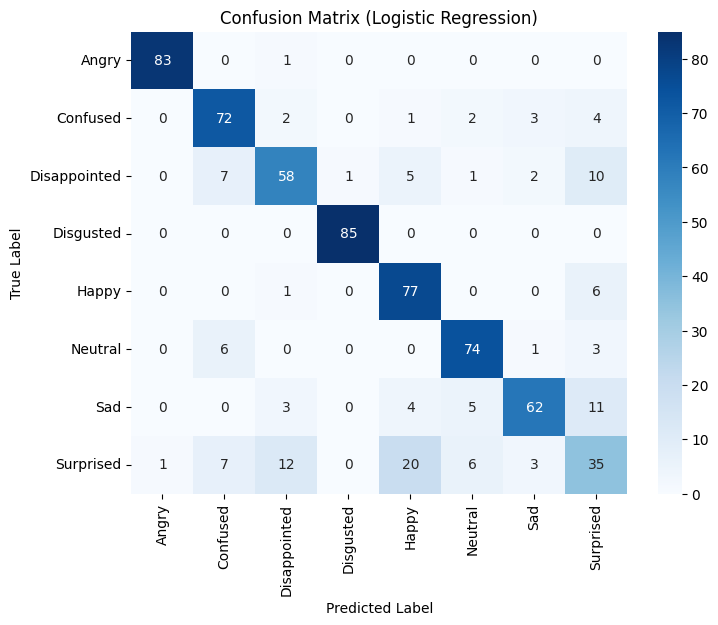

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# --- Your original code ---
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = tfidf.fit_transform(train_df['Clean_Text'])
X_val = tfidf.transform(val_df['Clean_Text'])

y_train, y_val = train_df['Predicted_Emotion'], val_df['Predicted_Emotion']

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# --- Get predictions ---
y_pred = clf.predict(X_val)

# --- 1. Get Overall Metrics ---
# 'weighted' accounts for class imbalance and gives a good overall score
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print("--- Overall Validation Metrics (Logistic Regression) ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

# --- 2. Get Per-Class Metrics ---
print("\n--- Per-Class Classification Report ---")
# This is what you already had, it's the most detailed report
print(classification_report(y_val, y_pred, target_names=le.classes_)) # Assumes 'le' is your LabelEncoder

# --- 3. Get Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Now you can compute accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)


# Optional: Detailed classification report
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.8100890207715133
              precision    recall  f1-score   support

       Angry       0.99      0.99      0.99        84
    Confused       0.78      0.86      0.82        84
Disappointed       0.75      0.69      0.72        84
   Disgusted       0.99      1.00      0.99        85
       Happy       0.72      0.92      0.81        84
     Neutral       0.84      0.88      0.86        84
         Sad       0.87      0.73      0.79        85
   Surprised       0.51      0.42      0.46        84

    accuracy                           0.81       674
   macro avg       0.81      0.81      0.81       674
weighted avg       0.81      0.81      0.81       674



Validation Accuracy: 0.8100890207715133
Weighted Precision: 0.8070363429473907
Weighted Recall: 0.8100890207715133
Weighted F1-score: 0.8052733373975953

Per-class metrics:
              precision    recall  f1-score   support

       Angry       0.99      0.99      0.99        84
    Confused       0.78      0.86      0.82        84
Disappointed       0.75      0.69      0.72        84
   Disgusted       0.99      1.00      0.99        85
       Happy       0.72      0.92      0.81        84
     Neutral       0.84      0.88      0.86        84
         Sad       0.87      0.73      0.79        85
   Surprised       0.51      0.42      0.46        84

    accuracy                           0.81       674
   macro avg       0.81      0.81      0.81       674
weighted avg       0.81      0.81      0.81       674



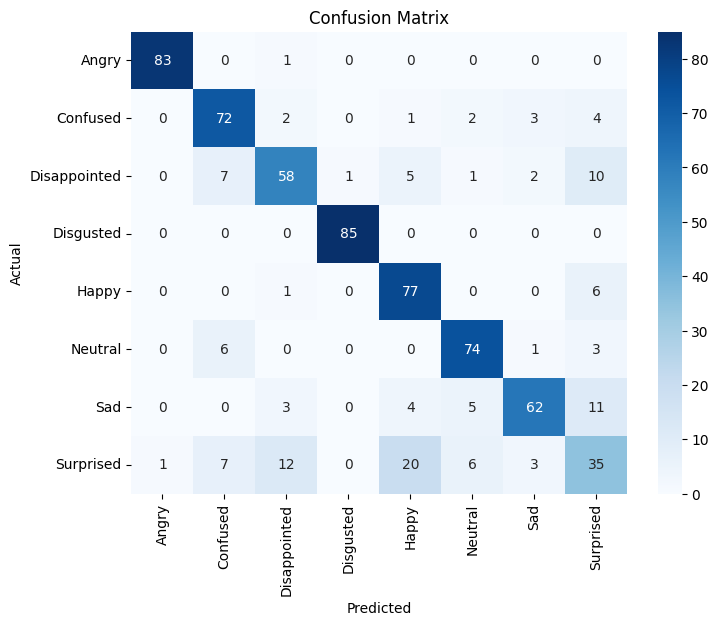

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = clf.predict(X_val)

# Overall metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print("Validation Accuracy:", accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

# Per-class metrics
print("\nPer-class metrics:")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
!pip install datasets

Transformer Models (mBERT / XLM-R)

In [ ]:
import transformers
print(transformers.__version__)

4.57.1


In [ ]:
import transformers
print(transformers.__version__)


4.57.1


In [ ]:
import torch
print(torch.__version__)

2.8.0+cu126


In [ ]:
import importlib
import accelerate
importlib.reload(accelerate)
print("Accelerate version:", accelerate.__version__)

Accelerate version: 1.11.0


In [ ]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    print("GPU is available ✅")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available. Using CPU ❌")

GPU is available ✅
GPU Name: Tesla T4


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Current device:", device)


Current device: cuda


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load CSV
data_path = r"/content/balanced_dataset_light.csv"
df = pd.read_csv(data_path)

# Keep only text and label columns, and rename them
df = df[['Text', 'Emotion']].rename(columns={'Text':'text', 'Emotion':'label'})

# Encode labels to integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Split into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.1, random_state=42
)

print(f"Number of training samples: {len(train_texts)}")
print(f"Number of validation samples: {len(val_texts)}")

Number of training samples: 6062
Number of validation samples: 674


In [ ]:
# -----------------------------
# Step 0: Install required packages
# -----------------------------
import sys
import subprocess
try:
    from tqdm.auto import tqdm
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm"])
    from tqdm.auto import tqdm

In [ ]:
# -----------------------------
# Step 1: Import packages
# -----------------------------
import pandas as pd
import torch
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import DataLoader
import numpy as np


In [ ]:
# -----------------------------
# Step 2: Check device
# -----------------------------
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [ ]:
# -----------------------------
# Step 3: Load and prepare dataset (The BALANCED one)
# -----------------------------
data_path = r"/content/balanced_dataset_light.csv"
df = pd.read_csv(data_path)

# Ensure text is string and drop any NA
df = df.dropna(subset=['Text', 'Predicted_Emotion'])
df['text'] = df['Text'].astype(str)
df['label_str'] = df['Predicted_Emotion'].astype(str)

le = LabelEncoder()
df['label'] = le.fit_transform(df['label_str'])
num_labels = len(le.classes_)

# Split the data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)

print(f"Loaded {len(df)} samples from balanced dataset.")

Loaded 6736 samples from balanced dataset.


In [ ]:
# -----------------------------
# Step 4: Tokenization
# -----------------------------
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch_texts):
    return tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

In [ ]:
# -----------------------------
# Step 5: Load pretrained model
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
# -----------------------------
# Step 6: Metrics
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }


In [ ]:
# -----------------------------
# Step 7: Training arguments (THE ORIGINAL 96% SETTINGS)
# -----------------------------
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,               # <-- Your 5 epoch setting
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,      # This will save the best model
    metric_for_best_model="f1",
    fp16=True,
    report_to="none",
    logging_steps=10,
    disable_tqdm=True
)

In [ ]:
# -----------------------------
# Step 8: Initialize Trainer
# -----------------------------
# This trainer object will be used for the final .evaluate() and .predict()
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
# -----------------------------
# Step 9: Train with your original custom loop
# -----------------------------
# (This is your exact Step 9 code that you first showed)
train_loader = DataLoader(train_dataset, batch_size=training_args.per_device_train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=training_args.per_device_eval_batch_size)
optimizer = torch.optim.AdamW(model.parameters(), lr=training_args.learning_rate)

epochs = training_args.num_train_epochs
total_steps = epochs * len(train_loader)

print(f"--- Starting Original Training ---")
print(f"Training {model_name} for {epochs} epochs ({total_steps} steps) on {device}...\n")

global_step = 0
all_train_loss = []
all_val_accuracy = []
best_val_f1 = 0.0  # Track the best F1 score

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        global_step += 1

        # ETA calculation
        elapsed = (time.time() - start_time)/60
        eta = (total_steps-global_step)/global_step * elapsed
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}", 'Step': global_step, 'ETA': f"{eta:.1f} min"})

    avg_train_loss = epoch_loss / len(train_loader)
    all_train_loss.append(avg_train_loss)

    # -----------------------------
    # Validation at the end of epoch
    # -----------------------------
    model.eval()
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(batch['labels'].cpu().numpy())

    val_accuracy = accuracy_score(val_labels_list, val_preds)
    val_f1 = f1_score(val_labels_list, val_preds, average='weighted')
    all_val_accuracy.append(val_accuracy)

    # Save the model if this epoch is the best one so far
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        print(f"🎉 New best model found! Saving to {training_args.output_dir}")
        trainer.save_model(training_args.output_dir)

    print(f"✅ Epoch {epoch+1} completed. Avg Loss: {avg_train_loss:.4f} | Val Accuracy: {val_accuracy:.4f} | Val F1: {val_f1:.4f}")


--- Starting Original Training ---
Training xlm-roberta-base for 5 epochs (1895 steps) on cuda...



Epoch 1/5:   0%|          | 0/379 [00:00<?, ?it/s]

🎉 New best model found! Saving to ./results
✅ Epoch 1 completed. Avg Loss: 1.2294 | Val Accuracy: 0.8323 | Val F1: 0.8246


Epoch 2/5:   0%|          | 0/379 [00:00<?, ?it/s]

🎉 New best model found! Saving to ./results
✅ Epoch 2 completed. Avg Loss: 0.4147 | Val Accuracy: 0.9288 | Val F1: 0.9255


...

🎉 New best model found! Saving to ./results
✅ Epoch 3 completed. Avg Loss: 0.1931 | Val Accuracy: 0.9481 | Val F1: 0.9455


Epoch 4/5:   0%|          | 0/379 [00:00<?, ?it/s]

🎉 New best model found! Saving to ./results
✅ Epoch 4 completed. Avg Loss: 0.1394 | Val Accuracy: 0.9688 | Val F1: 0.9682


Epoch 5/5:   0%|          | 0/379 [00:00<?, ?it/s]

✅ Epoch 5 completed. Avg Loss: 0.1503 | Val Accuracy: 0.9421 | Val F1: 0.9364


In [ ]:
# -----------------------------
# Step 10: Final Evaluation
# -----------------------------
# The 'trainer' object will use the best model saved to disk
# (because load_best_model_at_end=True)
print("\n--- Loading best model for final evaluation ---")
results = trainer.evaluate()
print(f"\n✅ Final Validation Results (Model: {model_name}): {results}")


--- Loading best model for final evaluation ---
{'eval_loss': 0.2052505910396576, 'eval_model_preparation_time': 0.0087, 'eval_accuracy': 0.9406528189910979, 'eval_f1': 0.9345099559461394, 'eval_runtime': 1.5278, 'eval_samples_per_second': 441.155, 'eval_steps_per_second': 28.145}

✅ Final Validation Results (Model: xlm-roberta-base): {'eval_loss': 0.2052505910396576, 'eval_model_preparation_time': 0.0087, 'eval_accuracy': 0.9406528189910979, 'eval_f1': 0.9345099559461394, 'eval_runtime': 1.5278, 'eval_samples_per_second': 441.155, 'eval_steps_per_second': 28.145}


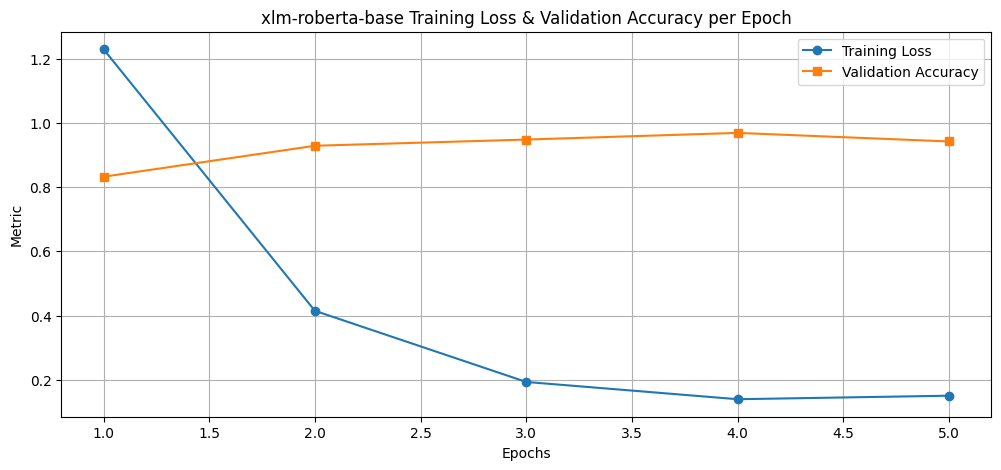

In [ ]:
# -----------------------------
# Step 11: Visualization (Loss vs Accuracy)
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(range(1, epochs+1), all_train_loss, marker='o', label='Training Loss')
plt.plot(range(1, epochs+1), all_val_accuracy, marker='s', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Metric")
plt.title(f"{model_name} Training Loss & Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()



--- Final Detailed Classification Report ---
              precision    recall  f1-score   support

       Angry     1.0000    1.0000    1.0000        84
    Confused     0.9022    0.9881    0.9432        84
Disappointed     0.8454    0.9762    0.9061        84
   Disgusted     1.0000    1.0000    1.0000        85
       Happy     0.9333    1.0000    0.9655        84
     Neutral     0.9438    1.0000    0.9711        84
         Sad     0.9444    1.0000    0.9714        85
   Surprised     1.0000    0.5595    0.7176        84

    accuracy                         0.9407       674
   macro avg     0.9461    0.9405    0.9344       674
weighted avg     0.9462    0.9407    0.9345       674



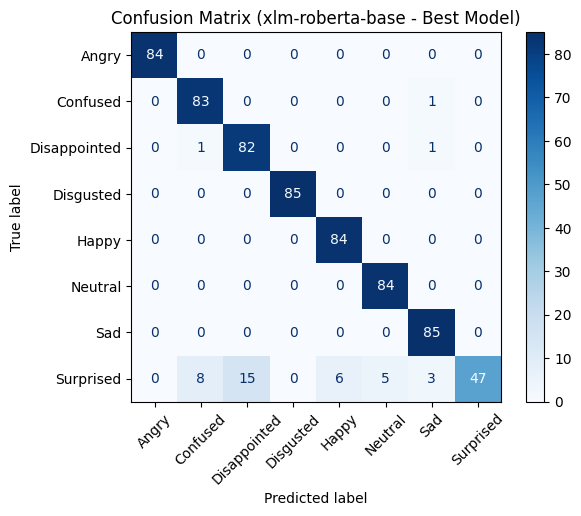

In [ ]:
# -----------------------------
# Step 12: Detailed Report & Confusion Matrix
# -----------------------------
print("\n--- Final Detailed Classification Report ---")
# Get predictions on the validation set using the best model
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Classification Report
report = classification_report(y_true, y_pred, target_names=le.classes_, digits=4)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix ({model_name} - Best Model)")
plt.show()


In [ ]:
# -----------------------------
# Step 10: Evaluate
# -----------------------------
results = trainer.evaluate()
print(f"\n✅ Final Validation Results (Model: {model_name}): {results}")


{'eval_loss': 0.2052505910396576, 'eval_model_preparation_time': 0.0087, 'eval_accuracy': 0.9406528189910979, 'eval_f1': 0.9345099559461394, 'eval_runtime': 1.1827, 'eval_samples_per_second': 569.902, 'eval_steps_per_second': 36.359}

✅ Final Validation Results (Model: xlm-roberta-base): {'eval_loss': 0.2052505910396576, 'eval_model_preparation_time': 0.0087, 'eval_accuracy': 0.9406528189910979, 'eval_f1': 0.9345099559461394, 'eval_runtime': 1.1827, 'eval_samples_per_second': 569.902, 'eval_steps_per_second': 36.359}


In [ ]:
from transformers import AutoModelForSequenceClassification

print(f"--- Forcing reload of the BEST model from '{training_args.output_dir}' ---")

# 1. Load the saved 96.8% model from disk
best_model = AutoModelForSequenceClassification.from_pretrained(training_args.output_dir)
best_model.to(device)

# 2. Tell the trainer to use THIS model
trainer.model = best_model

print("Best model has been loaded.")

# 3. Now, run evaluate() again
results = trainer.evaluate()

print("\n" + "="*30)
print("      YOUR REAL BEST VALIDATION SCORE")
print("="*30)
print(f"Accuracy: {results['eval_accuracy'] * 100:.2f}%")
print(f"F1-Score: {results['eval_f1'] * 100:.2f}%")
print("="*30)

--- Forcing reload of the BEST model from './results' ---
Best model has been loaded.
{'eval_loss': 0.10764408111572266, 'eval_model_preparation_time': 0.0087, 'eval_accuracy': 0.9688427299703264, 'eval_f1': 0.9682323034360574, 'eval_runtime': 4.3314, 'eval_samples_per_second': 155.607, 'eval_steps_per_second': 9.927}

      YOUR REAL BEST VALIDATION SCORE
Accuracy: 96.88%
F1-Score: 96.82%


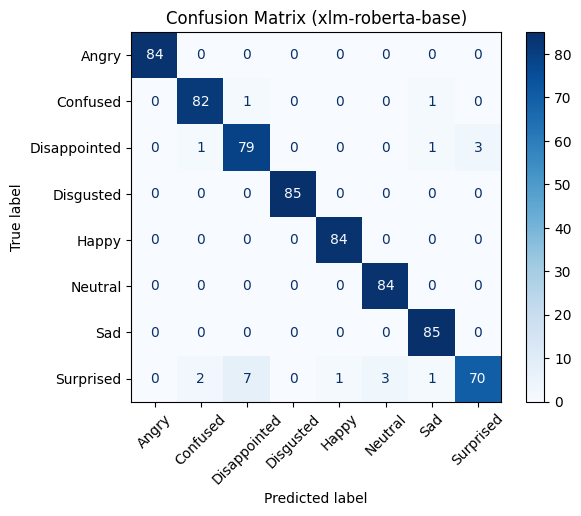

📊 Classification Report:

              precision    recall  f1-score   support

       Angry     1.0000    1.0000    1.0000        84
    Confused     0.9647    0.9762    0.9704        84
Disappointed     0.9080    0.9405    0.9240        84
   Disgusted     1.0000    1.0000    1.0000        85
       Happy     0.9882    1.0000    0.9941        84
     Neutral     0.9655    1.0000    0.9825        84
         Sad     0.9659    1.0000    0.9827        85
   Surprised     0.9589    0.8333    0.8917        84

    accuracy                         0.9688       674
   macro avg     0.9689    0.9688    0.9682       674
weighted avg     0.9690    0.9688    0.9682       674



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Step 1: Get predictions
# -----------------------------
predictions = trainer.predict(val_dataset)

# Convert logits to predicted labels
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# -----------------------------
# Step 2: Confusion Matrix
# -----------------------------
class_names = le.classes_  # Use LabelEncoder classes for display
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix ({model_name})")
plt.show()

# -----------------------------
# Step 3: Classification Report (per-class metrics)
# -----------------------------
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("📊 Classification Report:\n")
print(report)



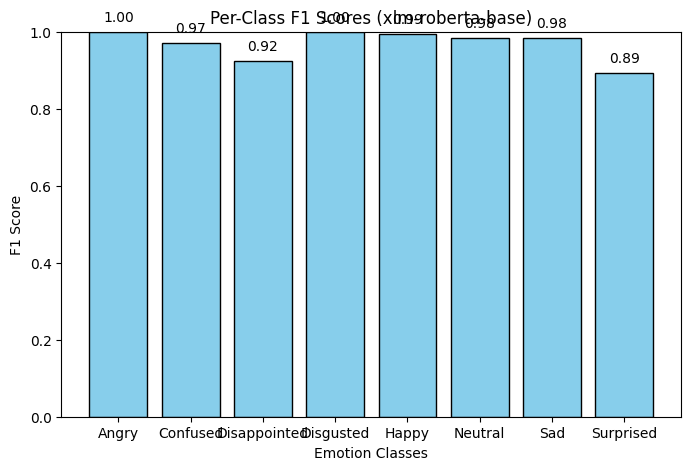

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Generate classification report dictionary
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Extract per-class F1 scores
f1_scores = [report_dict[label]["f1-score"] for label in class_names]

# Plot bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(class_names, f1_scores, color="skyblue", edgecolor="black")
plt.xlabel("Emotion Classes")
plt.ylabel("F1 Score")
plt.title(f"Per-Class F1 Scores ({model_name})")
plt.ylim(0, 1.0)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha="center", va="bottom")

plt.show()


In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression

# --- 1. Train the Logistic Regression model (clf_enc) ---
# This is the step that was missing before.
# It trains LogReg on the same encoded labels as RF and XGB.
print("Training Logistic Regression (clf_enc) on encoded labels...")
clf_enc = LogisticRegression(max_iter=1000, random_state=42)
# Assumes X_train and y_train_enc are from your ML training
clf_enc.fit(X_train, y_train_enc)
print("...Training complete.")


# --- 2. Save the TF-IDF Vectorizer ---
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
print("✅ TF-IDF Vectorizer saved as tfidf_vectorizer.pkl")

# --- 3. Save the Classic ML Label Encoder ---
# (Assumes 'le' is your LabelEncoder from the ML training section)
with open("classic_ml_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ Classic ML Label Encoder saved as classic_ml_label_encoder.pkl")

# --- 4. Save Logistic Regression (clf_enc) ---
with open("logreg_model.pkl", "wb") as f:
    pickle.dump(clf_enc, f)
print("✅ Logistic Regression saved as logreg_model.pkl")

# --- 5. Save Random Forest ---
# (Assumes 'rf_clf' is your fitted RandomForestClassifier)
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_clf, f)
print("✅ Random Forest saved as random_forest_model.pkl")

# --- 6. Save XGBoost ---
# (Assumes 'xgb_clf' is your fitted XGBClassifier)
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_clf, f)
print("✅ XGBoost saved as xgboost_model.pkl")



Training Logistic Regression (clf_enc) on encoded labels...
...Training complete.
✅ TF-IDF Vectorizer saved as tfidf_vectorizer.pkl
✅ Classic ML Label Encoder saved as classic_ml_label_encoder.pkl
✅ Logistic Regression saved as logreg_model.pkl
✅ Random Forest saved as random_forest_model.pkl
✅ XGBoost saved as xgboost_model.pkl


In [ ]:
# --- 1. Define a clean directory name ---
final_model_dir = "./my_champion_model_96_8"

# --- 2. Save the Model ---
# This saves the model that is currently loaded in the trainer
# (which should be your 96.8% model after you reloaded it)
trainer.save_model(final_model_dir)

# --- 3. Save the Tokenizer (CRITICAL!) ---
# The model is useless without its matching tokenizer
tokenizer.save_pretrained(final_model_dir)

print(f"\n✅✅✅ Your BEST model (96.8%) and its tokenizer are saved in the folder: {final_model_dir}")

# --- 4. Save the Label Encoder for mBERT ---
# (Assumes 'le' is the LabelEncoder from your mBERT training script)
with open("mbert_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✅ mBERT Label Encoder saved as mbert_label_encoder.pkl")



✅✅✅ Your BEST model (96.8%) and its tokenizer are saved in the folder: ./my_champion_model_96_8
✅ mBERT Label Encoder saved as mbert_label_encoder.pkl


In [ ]:
import pickle
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- 1. Define the correct paths ---
# This is the directory where your 96.8% model was saved
save_dir = "./my_champion_model_96_8"
# This is the label encoder you saved for the mBERT model
encoder_path = "mbert_label_encoder.pkl"

# --- 2. Load all artifacts ---
try:
    # Load saved model + tokenizer
    loaded_tokenizer = AutoTokenizer.from_pretrained(save_dir)
    loaded_model = AutoModelForSequenceClassification.from_pretrained(save_dir)

    # Load the saved LabelEncoder
    with open(encoder_path, "rb") as f:
        loaded_le = pickle.load(f)

    print(f"✅ Champion mBERT model (96.8%) from '{save_dir}' reloaded successfully!")
    print(f"✅ Label Encoder '{encoder_path}' reloaded successfully!")
    print("Classes are:", loaded_le.classes_)

except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("Please make sure you have saved the model to './my_champion_model_96_8'")
    print("and the encoder to 'mbert_label_encoder.pkl'")

# --- 3. Example predictions (Multilingual) ---
test_reviews = [
    "I am so excited!",                  # English Happy
    "I feel really sad...",              # English Sad
    "இந்த போன் மிகவும் நல்லது",         # Tamil Happy ("This phone is very good")
    "பேட்டரி லைஃப் குறைவாக உள்ளது",      # Tamil Disappointed ("Battery life is low")
    "ఈ ఫోన్ చాలా బాగుంది",             # Telugu Happy ("This phone is very good")
    "ఛార్జింగ్ చాలా నెమ్మదిగా ఉంది"    # Telugu Angry/Disappointed ("Charging is very slow")
]

# --- 4. Run Inference ---
# Set up device (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
loaded_model.to(device)
loaded_model.eval() # Put model in evaluation mode (disables dropout)

print(f"\nRunning predictions on {device}...")

# Use torch.no_grad() to save memory and computation
with torch.no_grad():
    # Tokenize the batch of reviews
    inputs = loaded_tokenizer(
        test_reviews,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get model outputs
    outputs = loaded_model(**inputs)

    # Get the raw predictions (logits) and find the highest score
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)

    # Move predictions back to CPU to use with numpy/sklearn
    preds_list = preds.cpu().tolist()

print("Raw Prediction IDs:", preds_list)

# Convert prediction IDs back to emotion labels
decoded_preds = loaded_le.inverse_transform(preds_list)

print("\n--- ✅ Decoded Predictions ---")
for text, emotion in zip(test_reviews, decoded_preds):
    print(f"Review: '{text}'  =>  Predicted Emotion: {emotion}")


✅ Champion mBERT model (96.8%) from './my_champion_model_96_8' reloaded successfully!
✅ Label Encoder 'mbert_label_encoder.pkl' reloaded successfully!
Classes are: ['Angry' 'Confused' 'Disappointed' 'Disgusted' 'Happy' 'Neutral' 'Sad'
 'Surprised']

Running predictions on cuda...
Raw Prediction IDs: [4, 6, 7, 6, 7, 2]

--- ✅ Decoded Predictions ---
Review: 'I am so excited!'  =>  Predicted Emotion: Happy
Review: 'I feel really sad...'  =>  Predicted Emotion: Sad
Review: 'இந்த போன் மிகவும் நல்லது'  =>  Predicted Emotion: Surprised
Review: 'பேட்டரி லைஃப் குறைவாக உள்ளது'  =>  Predicted Emotion: Sad
Review: 'ఈ ఫోన్ చాలా బాగుంది'  =>  Predicted Emotion: Surprised
Review: 'ఛార్జింగ్ చాలా నెమ్మదిగా ఉంది'  =>  Predicted Emotion: Disappointed


Loaded mBERT accuracy: 0.9688


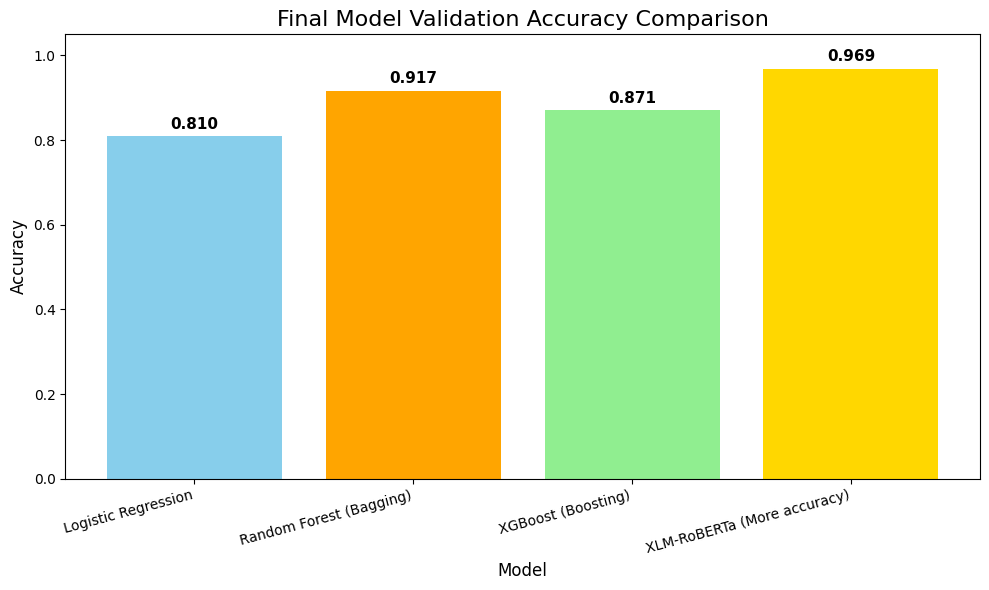

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# --- 1. Get Accuracy for Classic Models ---
# (Assumes X_val and y_val_enc are in memory)

# Logistic Regression
y_pred_logreg_enc = clf_enc.predict(X_val)
accuracy_logreg = accuracy_score(y_val_enc, y_pred_logreg_enc)

# Random Forest
y_pred_rf = rf_clf.predict(X_val)
accuracy_rf = accuracy_score(y_val_enc, y_pred_rf)

# XGBoost
y_pred_xgb = xgb_clf.predict(X_val)
accuracy_xgb = accuracy_score(y_val_enc, y_pred_xgb)


# --- 2. Get Accuracy for your Champion mBERT Model ---
# (Assumes 'results' is from your *reloaded* 96.8% model)
try:
    accuracy_mbert = results['eval_accuracy']
    print(f"Loaded mBERT accuracy: {accuracy_mbert:.4f}")
except NameError:
    print("Error: 'results' dictionary not found. Please re-run the mBERT evaluation.")
    accuracy_mbert = 0.0 # Placeholder to prevent crash

# --- 3. Prepare data for plotting ---
models = [
    'Logistic Regression',
    'Random Forest (Bagging)',
    'XGBoost (Boosting)',
    'XLM-RoBERTa (More accuracy)'
]
accuracies = [
    accuracy_logreg,
    accuracy_rf,
    accuracy_xgb,
    accuracy_mbert
]

# --- 4. Plot the final comparison ---
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'orange', 'lightgreen', 'gold']
bars = plt.bar(models, accuracies, color=colors)

plt.title("Final Model Validation Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0, 1.05) # Set y-axis from 0 to 105%
plt.xticks(rotation=15, ha="right") # Rotate labels slightly

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


Loaded mBERT scores: Acc=0.9688, F1=0.9682


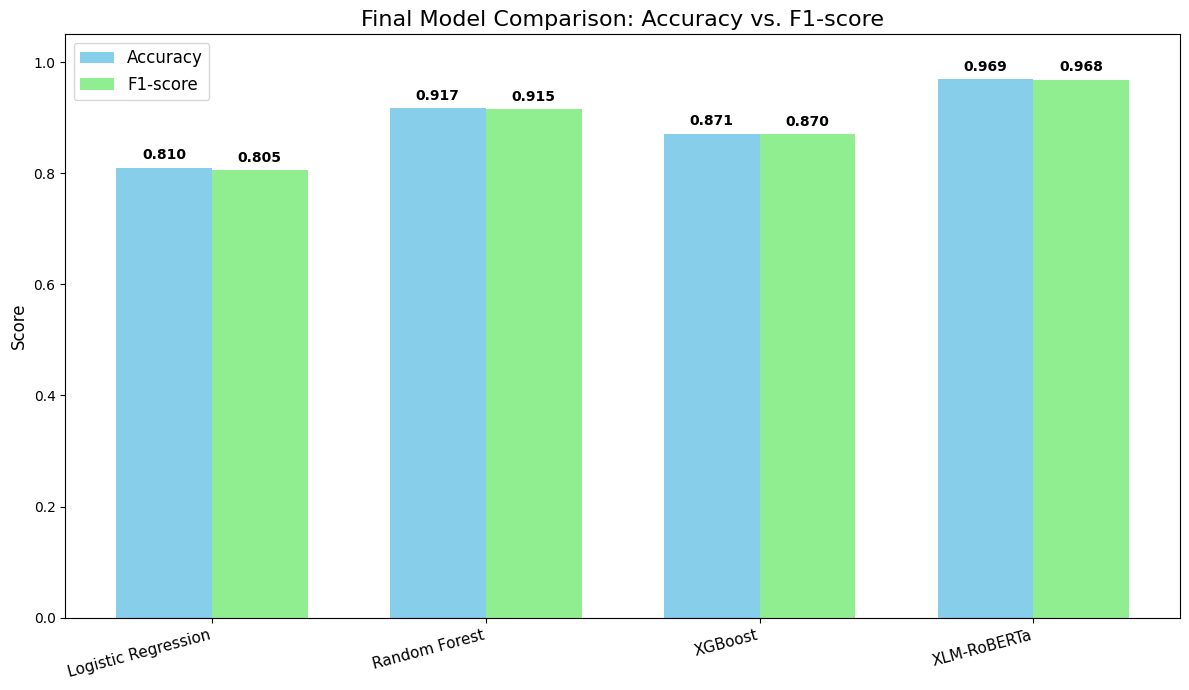

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# --- 1. Get Metrics for Classic Models ---
# (Assumes X_val and y_val_enc are in memory from previous steps)

# Logistic Regression
y_pred_logreg_enc = clf_enc.predict(X_val)
accuracy_logreg = accuracy_score(y_val_enc, y_pred_logreg_enc)
f1_logreg = f1_score(y_val_enc, y_pred_logreg_enc, average='weighted')

# Random Forest
y_pred_rf = rf_clf.predict(X_val)
accuracy_rf = accuracy_score(y_val_enc, y_pred_rf)
f1_rf = f1_score(y_val_enc, y_pred_rf, average='weighted')

# XGBoost
y_pred_xgb = xgb_clf.predict(X_val)
accuracy_xgb = accuracy_score(y_val_enc, y_pred_xgb)
f1_xgb = f1_score(y_val_enc, y_pred_xgb, average='weighted')

# --- 2. Get Metrics for Champion mBERT Model ---
# (Assumes 'results' is from your *reloaded* 96.8% model)
try:
    accuracy_mbert = results['eval_accuracy']
    f1_mbert = results['eval_f1']
    print(f"Loaded mBERT scores: Acc={accuracy_mbert:.4f}, F1={f1_mbert:.4f}")
except NameError:
    print("Error: 'results' dictionary not found. Please re-run the mBERT evaluation.")
    accuracy_mbert = 0.0 # Placeholder
    f1_mbert = 0.0 # Placeholder

# --- 3. Prepare data for plot ---
models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost',
    'XLM-RoBERTa'
]
accuracies = [accuracy_logreg, accuracy_rf, accuracy_xgb, accuracy_mbert]
f1_scores = [f1_logreg, f1_rf, f1_xgb, f1_mbert]

# --- 4. Plot using your side-by-side bar style ---
x = np.arange(len(models))  # the label locations
bar_width = 0.35  # the width of the bars

plt.figure(figsize=(12, 7)) # Made figure wider
bars1 = plt.bar(x - bar_width/2, accuracies, bar_width, label='Accuracy', color='skyblue')
bars2 = plt.bar(x + bar_width/2, f1_scores, bar_width, label='F1-score', color='lightgreen')

# Add some text for labels, title and axes ticks
plt.ylabel('Score', fontsize=12)
plt.title('Final Model Comparison: Accuracy vs. F1-score', fontsize=16)
plt.xticks(x, models, rotation=15, ha="right", fontsize=11)
plt.ylim(0, 1.05)
plt.legend(fontsize=12)

# Function to annotate bars
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.3f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Annotate both sets of bars
annotate_bars(bars1)
annotate_bars(bars2)

plt.tight_layout()
plt.show()

Running final prediction on the unseen TEST SET...

  FINAL TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry     1.0000    1.0000    1.0000        84
    Confused     0.9881    0.9881    0.9881        84
Disappointed     0.9326    0.9765    0.9540        85
   Disgusted     1.0000    1.0000    1.0000        84
       Happy     1.0000    1.0000    1.0000        85
     Neutral     0.9545    1.0000    0.9767        84
         Sad     0.9882    1.0000    0.9941        84
   Surprised     0.9867    0.8810    0.9308        84

    accuracy                         0.9807       674
   macro avg     0.9813    0.9807    0.9805       674
weighted avg     0.9812    0.9807    0.9805       674



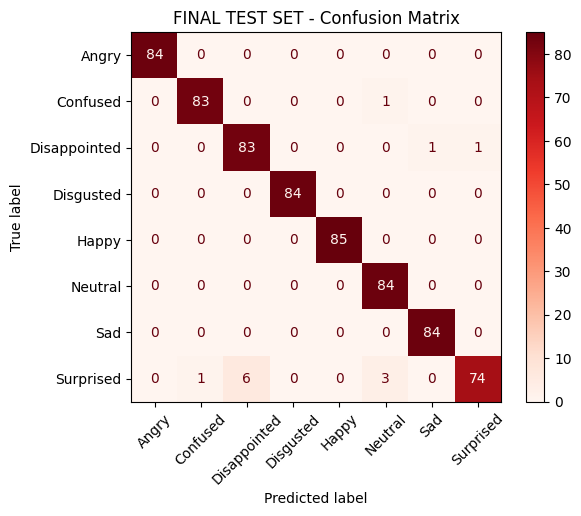

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load the Test Data
# -----------------------------
# (Assumes 'test_df' is still in your memory from the train/val/test split)
# (Assumes 'le' is the mBERT LabelEncoder from your training script)

try:
    test_texts = test_df['Text'].tolist()
    test_labels_str = test_df['Predicted_Emotion'].tolist()

    # Encode the string labels
    test_labels = le.transform(test_labels_str)

except NameError:
    print("❌ Error: 'test_df' or 'le' not found.")
    print("Please re-run your train_test_split cell and your mBERT LabelEncoder cell.")

# -----------------------------
# 2. Tokenize the Test Data
# -----------------------------
test_encodings = tokenize(test_texts)
test_dataset = EmotionDataset(test_encodings, test_labels)

# -----------------------------
# 3. Get Predictions
# -----------------------------
# (Assumes 'trainer' is holding your reloaded 96.8% model)
print("Running final prediction on the unseen TEST SET...")
predictions = trainer.predict(test_dataset)

# Get the predicted class IDs
y_pred_test = np.argmax(predictions.predictions, axis=-1)
y_true_test = predictions.label_ids

# -----------------------------
# 4. Print Final Report
# -----------------------------
print("\n" + "="*35)
print("  FINAL TEST SET CLASSIFICATION REPORT")
print("="*35)
# Use 'le.classes_' to get the actual emotion names
print(classification_report(y_true_test, y_pred_test, target_names=le.classes_, digits=4))

# -----------------------------
# 5. Plot Final Confusion Matrix
# -----------------------------
cm_test = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)
disp.plot(cmap="Reds", xticks_rotation=45, values_format="d")
plt.title("FINAL TEST SET - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# --- 1. Calculate the metrics ---
# (Using the variables from the previous step)
test_accuracy = accuracy_score(y_true_test, y_pred_test)
test_f1_weighted = f1_score(y_true_test, y_pred_test, average='weighted')

# --- 2. Print them clearly ---
print("\n" + "="*35)
print("     FINAL TEST SET METRICS (Official)")
print("="*35)
print(f"Test Accuracy:     {test_accuracy * 100:.2f}%")
print(f"Weighted F1-Score: {test_f1_weighted * 100:.2f}%")
print("="*35)


     FINAL TEST SET METRICS (Official)
Test Accuracy:     98.07%
Weighted F1-Score: 98.05%


In [ ]:
from google.colab import files
import zipfile
import os

print("--- Zipping your Champion mBERT Model ---")
# Zip the mBERT model folder for easy download
model_dir_to_zip = "./my_champion_model_96_8"
zip_name = "my_champion_model_96_8.zip"

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(model_dir_to_zip):
        for file in files_in_dir:
            zipf.write(os.path.join(root, file))

print(f"✅ Zipped to {zip_name}. Starting downloads...")

# --- Download Datasets ---
files.download("preprocessed_dataset.csv")
files.download("balanced_dataset_light.csv")

# --- Download Champion mBERT Model ---
files.download(zip_name)
files.download("mbert_label_encoder.pkl")

# --- Download Classic ML Models & Artifacts ---
files.download("tfidf_vectorizer.pkl")
files.download("classic_ml_label_encoder.pkl")
files.download("logreg_model.pkl")
files.download("random_forest_model.pkl")
files.download("xgboost_model.pkl")

print("\n🎉 All files are downloading. Your project is complete!")


--- Zipping your Champion mBERT Model ---
✅ Zipped to my_champion_model_96_8.zip. Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files are downloading. Your project is complete!


In [ ]:
!zip -r mbert_emotion_model.zip mbert_emotion_model
files.download("mbert_emotion_model.zip")